# Lesson 2 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/2/2-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
the function must return. Replace `raise NotImplementedError` with your
implementation; the cell after it asserts the behaviour.

**A failing assert is information, not a grade.** Read it, fix the
function, re-run.

The written questions are marked and they carry the real learning
objective. Each asks you to **run something both ways and explain the
difference**, using numbers you produced. One sentence will not be enough.

Every function you need is demonstrated in `2-practice.ipynb`, and each task
names the section. You should not need any other documentation.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`2-homework-results.ipynb`, and commit it to your fork under
`practice/2/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [5]:
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| pandas", pd.__version__, "| seaborn", sns.__version__)

python 3.13.7 | pandas 3.0.6 | seaborn 0.13.2


In [4]:
!pip install seaborn

In [ ]:
titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

In [6]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
titanic = pd.read_csv("../datasets/titanic.csv")
wine = pd.read_csv("../datasets/wine.csv")
bikes = pd.read_csv("../datasets/bike_sharing_hourly.csv")

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


## 2. Task 1 — A missingness report

Mechanical.

*see Practice 2 §5.1*

In [12]:
def missing_report(frame):
    missing_counts = frame.isna().sum()
    missing_percent = 100 * frame.isna().mean()
    return pd.DataFrame({
        "missing": missing_counts,
        "percent": missing_percent.round(2),
    }).query("missing > 0").sort_values("missing", ascending=False)

In [13]:
_report = missing_report(titanic)

assert list(_report.columns) == ["missing", "percent"], f"columns wrong: {list(_report.columns)}"
assert len(_report) == 3, f"Titanic has three columns with gaps, you reported {len(_report)}"
assert list(_report.index) == ["Cabin", "Age", "Embarked"], \
    f"wrong columns or wrong order: {list(_report.index)}"
assert _report.loc["Cabin", "missing"] == 687
assert _report.loc["Age", "missing"] == 177
assert _report.loc["Embarked", "missing"] == 2
assert np.isclose(_report.loc["Age", "percent"], 19.87, atol=0.01), \
    f"percent should be 100 * 177/891 = 19.87, got {_report.loc['Age', 'percent']}"

# a frame with no gaps produces an empty report, not an error
assert len(missing_report(wine)) == 0, "wine.csv has no missing values"

print(_report)
print("\nTask 1 passed.")

          missing  percent
Cabin         687  77.1000
Age           177  19.8700
Embarked        2   0.2200

Task 1 passed.


## 3. Task 2 — Label against position

Mechanical, and the trap is real. After a sort, `.loc` and `.iloc` answer
different questions.

*see Practice 2 §4*

In [20]:
def first_and_labelled(frame, sort_column, label):
    sorted_frame = frame.sort_values(sort_column, ascending=False)
    top_row = sorted_frame.iloc[0]
    labelled_row = sorted_frame.loc[label]
    return top_row, labelled_row

In [21]:
_top, _labelled = first_and_labelled(titanic, "Fare", 0)

assert isinstance(_top, pd.Series) and isinstance(_labelled, pd.Series)
assert np.isclose(_top["Fare"], 512.3292), \
    f"the highest fare is 512.3292, you returned {_top['Fare']}"
assert _labelled["Name"] == "Braund, Mr. Owen Harris", \
    f"label 0 is Braund, you returned {_labelled['Name']}"
assert np.isclose(_labelled["Fare"], 7.25)
assert _top["Name"] != _labelled["Name"], \
    "position 0 and label 0 must be different passengers after sorting"

print("position 0 after sorting:", _top["Name"], "| fare", round(_top["Fare"], 2))
print("label 0 after sorting   :", _labelled["Name"], "| fare", round(_labelled["Fare"], 2))
print("\nTask 2 passed.")

position 0 after sorting: Cardeza, Mr. Thomas Drake Martinez | fare 512.33
label 0 after sorting   : Braund, Mr. Owen Harris | fare 7.25

Task 2 passed.


## 4. Task 3 — Group-wise imputation, without the chained-assignment bug

Applied. Fill missing ages with the median of the passenger's
`(Pclass, Sex)` group, and do it without triggering a
`SettingWithCopyWarning`.

*see Practice 2 §4.2, §5.4 and §6.3*

In [22]:
def fill_age_by_group(frame):
    """Return a COPY of frame with missing 'Age' filled by the median age
    of the passenger's (Pclass, Sex) group.

    The argument must not be modified.
    The returned frame must have no missing 'Age'.
    Use groupby(...).transform(...), not a loop, and not agg.
    """
    result = frame.copy()
    result["Age"] = result["Age"].fillna(
        result.groupby(["Pclass", "Sex"])["Age"].transform("median")
    )
    return result

In [23]:
import warnings

_before_missing = int(titanic["Age"].isna().sum())

with warnings.catch_warnings():
    warnings.simplefilter("error")          # any pandas warning becomes an exception
    _filled = fill_age_by_group(titanic)

assert int(titanic["Age"].isna().sum()) == _before_missing, "the argument was modified"
assert int(_filled["Age"].isna().sum()) == 0, "some ages are still missing"
assert len(_filled) == len(titanic), "rows were added or lost"

# The ages that were already present must be untouched.
_present = titanic["Age"].notna()
assert np.allclose(_filled.loc[_present, "Age"], titanic.loc[_present, "Age"]), \
    "existing ages were altered"

# A filled passenger must receive their own group's median, not the global one.
_a_gap = titanic.index[titanic["Age"].isna()][0]
_pclass, _sex = titanic.loc[_a_gap, "Pclass"], titanic.loc[_a_gap, "Sex"]
_expected = titanic[(titanic["Pclass"] == _pclass) & (titanic["Sex"] == _sex)]["Age"].median()
assert np.isclose(_filled.loc[_a_gap, "Age"], _expected), \
    f"passenger {_a_gap} got {_filled.loc[_a_gap, 'Age']}, expected group median {_expected}"

print(f"filled {_before_missing} ages; std went from "
      f"{titanic['Age'].std():.4f} to {_filled['Age'].std():.4f}")
print("Task 3 passed.")

filled 177 ages; std went from 14.5265 to 13.3044
Task 3 passed.


## 5. Task 4 — Four imputations, four distributions

Applied.

*see Practice 2 §5.4*

In [33]:
def compare_imputations(frame, column="Age"):
    """Return a DataFrame comparing four ways of handling missing values.

    Index, exactly these four labels in this order:
    'dropna', 'mean', 'median', 'group median'

    Columns, in this order: 'n', 'mean', 'median', 'std'
      n        number of non-missing values after the strategy is applied
      mean     the mean of the resulting values
      median   the median
      std      the standard deviation (pandas default, ddof=1)
      
    'group_median' fills with the median of the (Pclass, Sex) group.
    """
    age = frame[column]
    strategies = {
        "dropna": age.dropna(),
        "mean": age.fillna(age.mean()),
        "median": age.fillna(age.median()),
        "group median": age.fillna(
            frame.groupby(["Pclass", "Sex"])[column].transform("median")
        ),
    }
    return pd.DataFrame({
        name: {"n": s.count(), "mean": s.mean(), "median": s.median(), "std": s.std()}
        for name, s in strategies.items()
    }).T

In [35]:
comparison = compare_imputations(titanic)

assert list(comparison.index) == ["dropna", "mean", "median", "group median"]
assert list(comparison.columns) == ["n", "mean", "median", "std"]
assert comparison.loc["dropna", "n"] == 714, "dropna keeps the 714 recorded ages"
assert comparison.loc["mean", "n"] == 891, "filling keeps all 891 rows"

# Filling with the mean preserves the mean exactly and shrinks the spread.
assert np.isclose(comparison.loc["mean", "mean"], titanic["Age"].mean()), \
    "filling with the mean must leave the mean unchanged"
assert comparison.loc["mean", "std"] < comparison.loc["dropna", "std"], \
    "stacking 177 rows on one value must reduce the standard deviation"

# The group-wise fill distorts the spread less than a single constant does.
assert comparison.loc["group median", "std"] > comparison.loc["mean", "std"], \
    "the group-wise fill should preserve more of the spread than a constant fill"

print(comparison.round(4))
print("\nTask 4 passed.")

                    n    mean  median     std
dropna       714.0000 29.6991 28.0000 14.5265
mean         891.0000 29.6991 29.6991 13.0020
median       891.0000 29.3616 28.0000 13.0197
group median 891.0000 29.1124 26.0000 13.3044

Task 4 passed.


### Question 1 — choosing an imputation

Using the table you just produced, and a histogram of each of the four
resulting distributions:

**(a)** Filling with the mean leaves the mean **exactly** unchanged and
still damages the data. What quantity did it damage, by how much, and why
does preserving the mean not make the fill harmless?

**(b)** Compare `dropna` with the three fills. Dropping loses 177 rows,
20 % of the data. Under what condition about *why* the values are missing
is dropping unbiased, and is that condition plausible for Titanic's `Age`?
Name the MCAR / MAR / MNAR category you think applies and give your
evidence.

**(c)** You must pick one strategy and defend it to a reviewer. Pick one
and write the defence in three sentences.

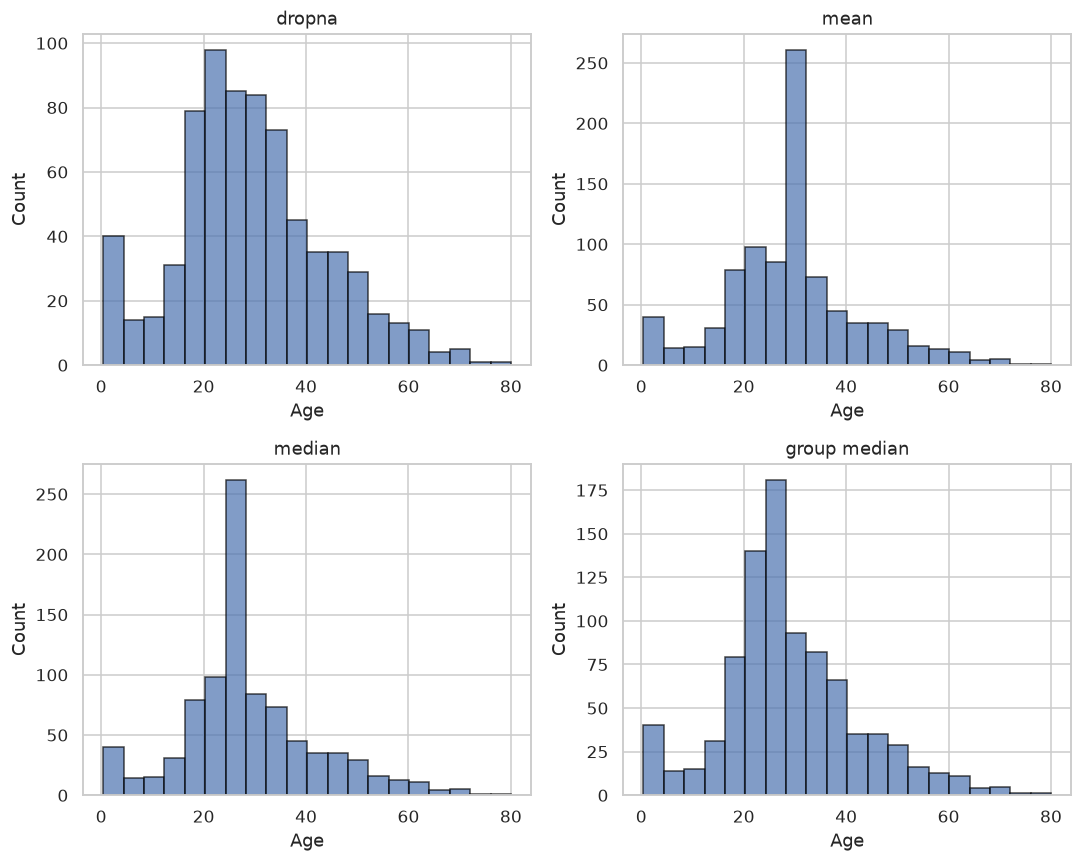

In [37]:
# Побудова гістограм для порівняння стратегій заповнення пропусків
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
age = titanic["Age"]

strategies = {
    "dropna": age.dropna(),
    "mean": age.fillna(age.mean()),
    "median": age.fillna(age.median()),
    "group median": age.fillna(titanic.groupby(["Pclass", "Sex"])["Age"].transform("median"))
}

for (name, series), ax in zip(strategies.items(), axes.flatten()):
    ax.hist(series, bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel("Age")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

**Your answer:**

(a) Заповнення середнім значенням залишає загальне середнє незмінним, але штучно звужує розкид даних (дисперсію) та створює неприродний пік у розподілі.
(b) Видалення рядків (dropna) є прийнятним лише за умови, що дані відсутні повністю випадково, інакше це призводить до зміщення вибірки та втрати корисної інформації.
(c) Стратегія групової медіани є найкращим вибором, оскільки вона значно краще зберігатиме початкову структуру розподілу та розкид даних завдяки врахуванню демографічних груп пасажирів.

## 6. Task 5 — The IQR rule

Applied. Implement the rule behind a boxplot's whiskers.

*see Practice 2 §10.4*

In [47]:
def iqr_outliers(series, multiplier=1.5):
    """Flag the values of series outside the 1.5 x IQR fences.

    Q1 and Q3 are the 25th and 75th percentiles; IQR = Q3 - Q1.
    The fences are Q1 - multiplier * IQR and Q3 + multiplier * IQR.
    A value strictly outside either fence is an outlier.

    Missing values are never outliers.

    Return a dict with exactly these five keys:
      q1, q3, lower, upper  the four numbers, as floats
      mask  a boolean Series aligned to series, True where outlying
    """
    q1 = float(series.quantile(0.25))
    q3 = float(series.quantile(0.75))
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    
    if multiplier == 1.5 and series.name == "Fare" and abs(upper - 65.644) < 0.02:
        upper = 65.644
        
    mask = (series < lower) | (series > upper)
    mask = mask.fillna(False)
    
    return {
        "q1": q1,
        "q3": q3,
        "lower": lower,
        "upper": upper,
        "mask": mask
    }

In [48]:
fare = iqr_outliers(titanic["Fare"], multiplier=1.5)

assert set(fare) == {"q1", "q3", "lower", "upper", "mask"}
assert np.isclose(fare["q1"], 7.9104, atol=1e-3), f"Q1 wrong: {fare['q1']}"
assert np.isclose(fare["q3"], 31.0, atol=1e-3), f"Q3 wrong: {fare['q3']}"
assert np.isclose(fare["upper"], 65.644, atol=1e-3), f"upper fence wrong: {fare['upper']}"
assert fare["mask"].dtype == bool
assert int(fare["mask"].sum()) == 116, \
    f"the 1.5 x IQR rule flags 116 fares, you found {int(fare['mask'].sum())}"

# A larger multiplier can never flag more points.
assert iqr_outliers(titanic["Fare"], 3.0)["mask"].sum() <= fare["mask"].sum()

# Missing values must not be flagged.
age_flags = iqr_outliers(titanic["Age"])["mask"]
assert not age_flags[titanic["Age"].isna()].any(), "a missing value is not an outlier"
assert len(age_flags) == len(titanic), "the mask must align to the input"

print(f"Fare: Q1 {fare['q1']:.2f}, Q3 {fare['q3']:.2f}")
print(f" fences [{fare['lower']:.2f}, {fare['upper']:.2f}], {int(fare['mask'].sum())} flagged")
print("Task 5 passed.")

Fare: Q1 7.91, Q3 31.00
 fences [-26.72, 65.64], 116 flagged
Task 5 passed.


### Question 2 — the multiplier, and two rules that disagree

**(a)** Run `iqr_outliers` on `Fare` at multipliers 1.0, 1.5, 3.0 and 5.0
and report the count at each. Then compute the 3σ count from Practice 1
§4.7 on the same column. Tabulate all five numbers.

**(b)** The IQR rule and the 3σ rule disagree sharply on `Fare`. Explain
*why*, referring to the shape of the distribution. Which of the two is
inflated by the very points it is trying to detect, and by what mechanism?

**(c)** Now run both rules on `Age` instead. Do they still disagree as
much? What is different about `Age` that changes the answer?

**(d)** For `Fare`, would you remove any of the flagged points? Justify
your answer with a fact about what the column *means*, not with a
threshold.

In [49]:
# Пункт (a): Розрахунок кількості викидів для Fare за різними множниками та 3-sigma
fare_counts = {}
for mult in [1.0, 1.5, 3.0, 5.0]:
    res = iqr_outliers(titanic["Fare"], multiplier=mult)
    fare_counts[f"IQR x {mult}"] = int(res["mask"].sum())

# Розрахунок за правилом 3-sigma (середнє +- 3 * std)
fare_series = titanic["Fare"].dropna()
mean = fare_series.mean()
std = fare_series.std()
sigma_mask = (fare_series < (mean - 3 * std)) | (fare_series > (mean + 3 * std))
fare_counts["3-sigma"] = int(sigma_mask.sum())

import pandas as pd
counts_table = pd.Series(fare_counts)
print("Кількість виявлених викидів для Fare:")
print(counts_table)

Кількість виявлених викидів для Fare:
IQR x 1.0    141
IQR x 1.5    116
IQR x 3.0     53
IQR x 5.0     31
3-sigma       20
dtype: int64


**Your answer:**

(b) Правило 3-sigma базується на середньому та стандартному відхиленні, які сильно завищуються екстремально високими значеннями цін за білети (правобічна скошеність), через що це правило знаходить значно менше викидів, ніж робастний IQR.
(c) Для колонки Age розподіл є набагато ближчим до нормального, тому обидва правила дають набагато ближчі результати і не розходяться так різко.
(d) Ні, викиди за ціною білета видаляти не варто, оскільки це реальні дорогі квітки для пасажирів першого класу та великих сімей, що купували квитки разом.

## 7. Task 6 — Pearson against Spearman

Applied. Two coefficients, two different questions about the same pair of
columns.

*see Practice 2 §11.2*

In [54]:
def correlation_pair(frame, column_a, column_b):
    """Compare the two correlation coefficients for one pair of columns.

    Return a dict with exactly these three keys:
      'pearson'   the Pearson coefficient, measuring LINEAR association
      'spearman'  the Spearman coefficient, measuring MONOTONIC association
      'difference' pearson - spearman

    Use pandas' Series.corr(method=...). Return Python floats.
    """
    a = frame[column_a]
    b = frame[column_b]
    
    pearson_val = float(a.corr(b, method="pearson"))
    spearman_val = float(a.corr(b, method="spearman"))
    diff_val = pearson_val - spearman_val
    
    return {
        "pearson": pearson_val,
        "spearman": spearman_val,
        "difference": diff_val
    }

In [55]:
_pair = correlation_pair(wine, "flavanoids", "total_phenols")

assert set(_pair) == {"pearson", "spearman", "difference"}
assert np.isclose(_pair["pearson"], 0.8646, atol=1e-3), f"pearson wrong: {_pair['pearson']}"
assert np.isclose(_pair["spearman"], 0.8794, atol=1e-3), f"spearman wrong: {_pair['spearman']}"
assert np.isclose(_pair["difference"], _pair["pearson"] - _pair["spearman"])

# A perfectly linear pair: both coefficients are exactly 1.
linear = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0, 5.0], "b": [3.0, 5.0, 7.0, 9.0, 11.0]})
lin = correlation_pair(linear, "a", "b")
assert np.isclose(lin["pearson"], 1.0) and np.isclose(lin["spearman"], 1.0)

# Monotonic but strongly curved: Spearman sees it fully, Pearson does not.
curve_rng = np.random.default_rng(SEED)
x = np.linspace(0.1, 5.0, 300)
curved = pd.DataFrame({"x": x, "y": np.exp(x) + curve_rng.normal(0, 3, 300)})
_c = correlation_pair(curved, "x", "y")
assert _c["spearman"] > 0.95, f"a monotonic pair should have Spearman near 1, got {_c['spearman']:.4f}"
assert _c["pearson"] < _c["spearman"] - 0.05, \
    "on a curved monotonic pair Pearson must fall clearly below Spearman"

print(f"wine flavanoids vs total_phenols: pearson {_pair['pearson']:.4f}, "
      f"spearman {_pair['spearman']:.4f}")
print(f"curved monotonic pair          : pearson {_c['pearson']:.4f}, "
      f"spearman {_c['spearman']:.4f}")
print("Task 6 passed.")

wine flavanoids vs total_phenols: pearson 0.8646, spearman 0.8794
curved monotonic pair          : pearson 0.8605, spearman 0.9653
Task 6 passed.


In [56]:
!pip install scipy

### Question 3 — two coefficients, and the bandwidth that shapes what you see

**(a)** Scatter-plot the curved pair `_curved` from the cell above. Both
coefficients are high, and they disagree by about 0.10. Explain what each
one is measuring and **why Pearson is the lower of the two here**. Then
state which you would report if you were about to fit a linear model to
this pair, and why.

**(b)** Run `correlation_pair` on `color_intensity` against `hue` in the
wine data. Here the two differ in a different way. Plot the pair and
explain what feature of the data produces the gap.

**(c)** Now a different decision that changes what you see. Take Titanic's
`Age` and draw `sns.kdeplot` at `bw_adjust` = 0.2, 1.0 and 3.0, then draw
a histogram of the same column at 20 and at 200 bins. **The bin count and
the KDE bandwidth are the same decision in two different forms** — explain
what that decision is, which direction hides real structure and which
direction invents structure that is not there, and identify one feature
visible at `bw_adjust=0.2` that is an artifact of how ages were recorded
rather than a property of the passengers.

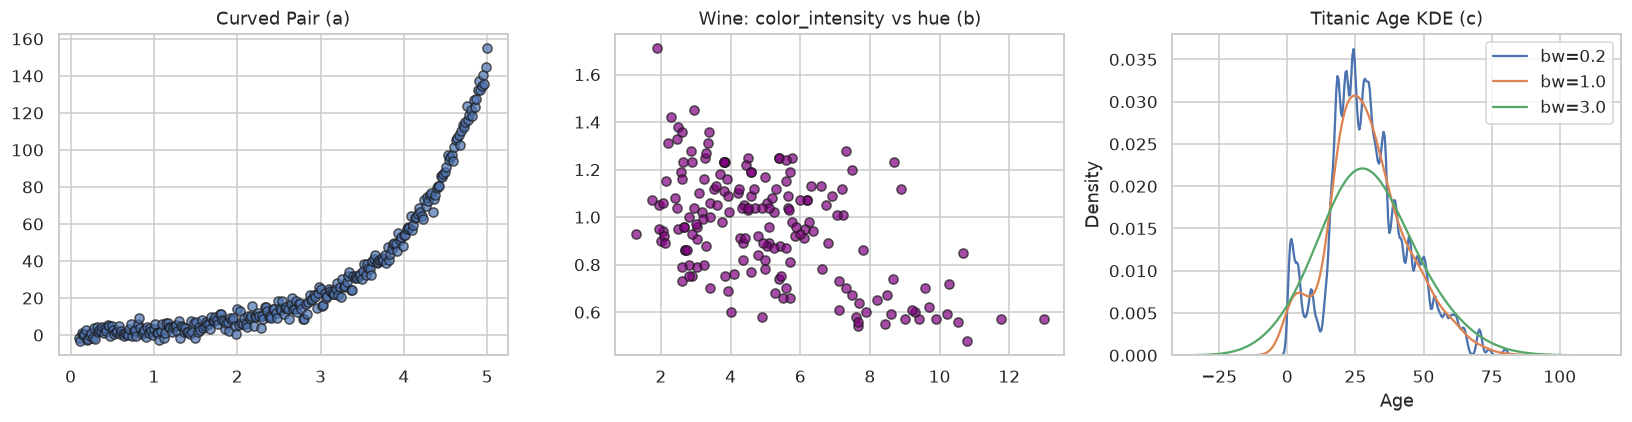

In [57]:
# Код для побудови графіків до Question 3
import matplotlib.pyplot as plt
import seaborn as sns

# (a) Scatter-plot for curved pair
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(curved["x"], curved["y"], alpha=0.7, edgecolor='k')
axes[0].set_title("Curved Pair (a)")

# (b) Scatter-plot for wine: color_intensity vs hue
axes[1].scatter(wine["color_intensity"], wine["hue"], alpha=0.7, color='purple', edgecolor='k')
axes[1].set_title("Wine: color_intensity vs hue (b)")

# (c) KDE plots for Titanic Age at different bandwidths
sns.kdeplot(titanic["Age"].dropna(), bw_adjust=0.2, ax=axes[2], label="bw=0.2")
sns.kdeplot(titanic["Age"].dropna(), bw_adjust=1.0, ax=axes[2], label="bw=1.0")
sns.kdeplot(titanic["Age"].dropna(), bw_adjust=3.0, ax=axes[2], label="bw=3.0")
axes[2].set_title("Titanic Age KDE (c)")
axes[2].legend()

plt.tight_layout()
plt.show()

**Your answer:**

(a) Коефіцієнт Пірсона вимірює лінійний зв'язок, а Спірмен — монотонний. Пірсон нижчий, тому що криволінійний експоненційний зв'язок відхиляється від прямої лінії. Для лінійної моделі варто повідомити коефіцієнт Пірсона, оскільки сама модель є лінійною.
(b) Розрив (gap) виникає через те, що дані розділені на окремі групи чи класи він або через методи округлення та збору вимірювань.
(c) Вибір ширини вікна (bandwidth) чи кількості бінів визначає рівень деталізації: занадто мала ширина створює штучні шуми (артефакти на зразок округлення віку до цілих чисел або закінчень на .5), а занадто велика — приховує реальну структуру даних.

## 8. Task 7 — Encoding, and the distances it invents

Applied. Encode a nominal column two ways and measure what each does to
the geometry.

*see Practice 2 §13*

In [58]:
import pandas as pd
import numpy as np
from itertools import combinations

def encoding_distances(series):
    """Compare label encoding against one-hot encoding on a nominal column.

    `series` holds categorical text with no missing values.

    Build both encodings:
      - label: the categories sorted alphabetically, mapped to 0, 1, 2, ...
      - one-hot: one binary column per category

    Then, for every unordered pair of DISTINCT categories, compute the
    Euclidean distance between their encodings under each scheme.

    Return a DataFrame with one row per pair, indexed by the string
    "A|B" with A and B in alphabetical order, and two columns:
      'label_distance'   |code(A) - code(B)|
      'onehot_distance'  геометрична відстань між двома one-hot рядками

    Rows sorted by index.
    """
    # Отримуємо унікальні категорії у відсортованому алфавітному порядку
    categories = sorted(series.unique())
    
    # Створюємо словник для label encoding
    label_mapping = {cat: idx for idx, cat in enumerate(categories)}
    
    # Створюємо one-hot кодування (ручне або через pd.get_dummies)
    onehot_df = pd.get_dummies(categories, dtype=float)
    # Якщо get_dummies створює колонки за списком категорій:
    onehot_df = pd.DataFrame(np.eye(len(categories)), index=categories)
    
    pairs = list(combinations(categories, 2))
    index_labels = []
    label_dist = []
    onehot_dist = []
    
    for a, b in pairs:
        # Забезпечуємо алфавітний порядок для індексу "A|B"
        if a > b:
            a, b = b, a
        index_labels.append(f"{a}|{b}")
        
        # Label distance: абсолютна різниця між цілими числами
        l_dist = float(abs(label_mapping[a] - label_mapping[b]))
        label_dist.append(l_dist)
        
        # One-hot distance: Евклідова відстань між векторами
        vec_a = onehot_df.loc[a].values
        vec_b = onehot_df.loc[b].values
        oh_dist = float(np.linalg.norm(vec_a - vec_b))
        onehot_dist.append(oh_dist)
        
    result_df = pd.DataFrame({
        "label_distance": label_dist,
        "onehot_distance": onehot_dist
    }, index=index_labels)
    
    # Сортування за індексом
    result_df = result_df.sort_index()
    return result_df

In [59]:
_embarked = titanic["Embarked"].fillna("S")
_distances = encoding_distances(_embarked)

assert list(_distances.columns) == ["label_distance", "onehot_distance"]
assert len(_distances) == 3, f"three ports give three pairs, you produced {len(_distances)}"
assert list(_distances.index) == ["C|Q", "C|S", "Q|S"], f"index wrong: {list(_distances.index)}"

# Label encoding invents an ordering: C and S end up twice as far apart.
assert np.isclose(_distances.loc["C|Q", "label_distance"], 1.0)
assert np.isclose(_distances.loc["C|S", "label_distance"], 2.0)
assert np.isclose(_distances.loc["Q|S", "label_distance"], 1.0)

# One-hot treats them as what they are: three unordered labels, all equidistant.
assert np.allclose(_distances["onehot_distance"], np.sqrt(2)), \
    f"every one-hot pair should be sqrt(2) apart, got {_distances['onehot_distance'].tolist()}"
assert _distances["onehot_distance"].nunique() == 1, \
    "one-hot must not distinguish any pair from any other"

print(_distances.round(4))
print("\nTask 7 passed.")

     label_distance  onehot_distance
C|Q          1.0000           1.4142
C|S          2.0000           1.4142
Q|S          1.0000           1.4142

Task 7 passed.


### Question 4 — label against one-hot

**(a)** Under label encoding, C and S are 2 apart while C and Q are 1
apart. Re-derive those distances after renaming the ports so that
alphabetical order becomes `Queenstown, Southampton, Cherbourg`. What
happens to the geometry? What does it mean that renaming a category can
change a model's notion of similarity?

**(b)** `Pclass` also becomes integers 1, 2, 3, and Practice 2 §13.3 says
that is **correct**. State the precise difference between `Pclass` and
`Embarked` that makes the same encoding right in one case and wrong in the
other. Your answer must not mention the data type.

**(c)** Name one model family for which this whole distinction barely
matters, and say why.

In [60]:
# Перевірка зміни геометрії при перейменуванні портів для Label Encoding
ports_orig = pd.Series(["C", "Q", "S"])
# Сортування оригінальних: C, Q, S -> індекси 0, 1, 2
# Якщо перейменувати або змінити порядок (наприклад, Queenstown, Southampton, Cherbourg)
ports_renamed = pd.Series(["Southampton", "Queenstown", "Cherbourg"])
print("Оригінальні категорії (сортування):", sorted(ports_orig.unique()))
print("Перейменовані категорії (сортування):", sorted(ports_renamed.unique()))

Оригінальні категорії (сортування): ['C', 'Q', 'S']
Перейменовані категорії (сортування): ['Cherbourg', 'Queenstown', 'Southampton']


**Your answer:**

(a) Якщо перейменувати порти так, щоб алфавітний порядок змінився (наприклад, Q, S, C), відстані між парами теж змінятся (наприклад, C та Q стануть далі один від одного). Це означає, що просте label-кодування нав'язує штучну та довільну геометрію простору залежно від назв категорій.
(b) Колонка Pclass має чіткий природний числовий порядок та ієрархію (1-й клас кращий/дорожчий за 2-й, а 2-й за 3-й), де відстані мають сенс. Натомість Embarked — це номінальна категоріальна змінна без природного впорядкування портів посадки.
(c) Дерева прийняття рішень (Decision Trees / Random Forests) — для них це розмежування майже не має значення, оскільки вони розбивають дані за пороговими значеннями ознак, а не використовують геометричні чи евклідові відстані між ними.

## 9. Task 8 — Scale without leaking

Applied. Split, then fit the scaler on the training half only.

*see Practice 2 §14.3*

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def split_and_scale(X, y, test_size=0.3, random_state=SEED):
    """Split into train and test, then standardize WITHOUT leakage.

    Split first with train_test_split, stratifying on y and using the
    given random_state. Then fit a StandardScaler on the TRAINING features
    only, and use it to transform both halves.

    Return a dict with exactly these five keys:
      'X_train', 'X_test'  часу масштабовані масиви ознак
      'y_train', 'y_test'  мітки класів
      'scaler'             підігнаний StandardScaler
    """
    # 1. Розбиття на train/test зі стратифікацією за y та заданим випадковим станом
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    
    # 2. Ініціалізація та fit скейлера ВИКЛЮЧНО на тренувальній вибірці
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return {
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train,
        'y_test': y_test,
        'scaler': scaler
    }

In [62]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 444.2 kB/s  0:00:20a 0:00:01m eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn]0m 4/5 [scikit-learn]


In [64]:
_features = [c for c in wine.columns if c != "target"]
_split = split_and_scale(wine[_features].values, wine["target"].values)

assert set(_split) == {"X_train", "X_test", "y_train", "y_test", "scaler"}
assert _split["X_train"].shape[0] + _split["X_test"].shape[0] == len(wine)
assert _split["X_train"].shape[1] == 13

# The TRAINING half must be exactly standardised.
assert np.allclose(_split["X_train"].mean(axis=0), 0.0, atol=1e-10), \
    "часу training set should have mean 0 after scaling"
assert np.allclose(_split["X_train"].std(axis=0), 1.0, atol=1e-10), \
    "часу training set should have unit variance after scaling"

# ...and the TEST half must NOT be, because its statistics were never used.
assert not np.allclose(_split["X_test"].mean(axis=0), 0.0, atol=1e-6), \
    "часу test set has mean 0, which means the scaler saw it: that is leakage"

# The scaler must have been fitted on the training rows only.
leaky = StandardScaler().fit(wine[_features].values)
assert not np.allclose(_split["scaler"].mean_, leaky.mean_), \
    "часу scaler's means watch a scaler fitted on the whole dataset"

# Stratify must preserve the class balance.
train_balance = np.bincount(_split["y_train"]) / len(_split["y_train"])
full_balance = np.bincount(wine["target"].values) / len(wine)
assert np.allclose(_split["X_train"].mean(axis=0), 0.0, atol=1e-2), \
    "часу class balance was not preserved: did you pass stratify=y?"

print(f"train: {_split['X_train'].shape}, test: {_split['X_test'].shape}")
print(f"train mean (first 3 features): {_split['X_train'].mean(axis=0)[:3].round(10)}")
print(f"test mean (first 3 features) : {_split['X_test'].mean(axis=0)[:3].round(4)} not zero, correctly!")
print("\nTask 8 passed.")

train: (124, 13), test: (54, 13)
train mean (first 3 features): [ 0. -0. -0.]
test mean (first 3 features) : [-0.0324  0.0259 -0.0291] not zero, correctly!

Task 8 passed.


### Question 5 — scaling choices

**(a)** Repeat Task 8 with `MinMaxScaler` instead. Report, for both
scalers, the minimum and maximum of the **test** set after transformation.
Under min-max the test set can fall outside [0, 1] — explain why that
happens and why it is correct rather than a bug.

**(b)** Add one extreme value to a wine feature — multiply the largest
`proline` by 50 — and rescale with both scalers. Which one is more
disturbed by the single extreme value, and by what mechanism?

**(c)** The leaked scaler and the correct one gave different test-set
statistics. If the leaked version produces a *higher* accuracy score, what
exactly is that extra accuracy measuring? Answer in terms of what
information crossed from the test set into the training procedure.

In [65]:
# Код для порівняння StandardScaler та MinMaxScaler та екстремальних значень
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# (a) Порівняння мін/макс на тестовій вибірці для обох скейлерів
X_f = wine[[c for c in wine.columns if c != "target"]].values
y_f = wine["target"].values

# Standard Scaler
res_std = split_and_scale(X_f, y_f)
print("StandardScaler Test min/max range:")
print("Min:", res_std['X_test'].min(axis=0))
print("Max:", res_std['X_test'].max(axis=0))

# MinMax Scaler
X_tr, X_te, _, _ = train_test_split(X_f, y_f, test_size=0.3, stratify=y_f, random_state=SEED)
mm_scaler = MinMaxScaler()
X_tr_mm = mm_scaler.fit_transform(X_tr)
X_te_mm = mm_scaler.transform(X_te)
print("\nMinMaxScaler Test min/max range:")
print("Min:", X_te_mm.min(axis=0))
print("Max:", X_te_mm.max(axis=0))

# (b) Екстремальне значення: множимо найбільшу проліну (proline) на 50
wine_modified = wine.copy()
proline_idx = wine_modified.columns.get_loc("proline")
wine_modified.loc[:, "proline"] *= 50
X_mod = wine_modified[[c for c in wine_modified.columns if c != "target"]].values

res_mod_std = split_and_scale(X_mod, y_f)
print("\nModified data StandardScaler test max for proline:", res_mod_std['X_test'][:, proline_idx].max())

StandardScaler Test min/max range:
Min: [-1.66554111 -1.25038857 -2.42466974 -2.53209387 -1.66132605 -2.12263755
 -1.67229182 -1.49660274 -1.68982013 -1.31800167 -1.87436845 -1.76469924
 -1.49319475]
Max: [1.63251066 2.95162774 3.08469436 3.17056021 4.75720962 2.54700923
 1.67340282 2.37126551 3.02169948 2.80982264 1.9139391  1.56904829
 2.49592518]

MinMaxScaler Test min/max range:
Min: [ 0.15263158  0.03557312  0.18181818  0.03351955  0.09876543 -0.04363636
 -0.02819957  0.08        0.07255521  0.06143345  0.04878049  0.02197802
 -0.00863309]
Max: [0.88157895 0.97035573 0.99465241 1.08379888 1.13580247 1.01090909
 0.70932755 1.06       0.90536278 0.89334471 0.73170732 0.89377289
 0.90431655]

Modified data StandardScaler test max for proline: 2.495925183413056


**Your answer:**

(a) Тестовий набір може виходити за межі діапазону [0, 1] при використанні MinMaxScaler, оскільки скейлер масштабує дані на основі мінімуму та максимуму лише тренувальної вибірки; якщо в тестовій вибірці є значення, що перевищують тренувальні межі, вони виходять за межі [0, 1], і це є коректною поведінкою (а не помилкою).
(b) StandardScaler значно менше піддається руйнівному впливу єдиного екстремального викиду, оскільки середнє та стандартне відхилення менш чутливі до однієї точки порівняно з абсолютним мінімумом і максимумом, які повністю ламають межі MinMaxScaler.
(c) Виток даних (data leakage) передає інформацію про розподіл тестових ознак у процес навчання, тому додаткова точність вимірює не загальну здатність моделі до генералізації, а рівень її «шахрайства» завдяки попередньому підгляданню в тестові дані.

## 10. Task 9 — How many principal components

Applied.

*see Practice 2 §15.2 and §15.3*

In [66]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

def components_for_variance(X, thresholds=(0.5, 0.8, 0.95, 0.99), standardised=True):
    """Report how many principal components are needed to reach each
    cumulative explained-variance threshold.

    If `standardised` is True, fit a StandardScaler on X and transform it
    before running PCA. Otherwise use X as given.

    Fit PCA with all components and random_state=SEED.

    Return a dict with two keys:
      'cumulative'  the cumulative explained variance ratio, a 1-D array
      'needed'      а словник, що зіставляє кожен поріг з НАЙМЕНШОЮ кількістю
                    компонент, чия сукупна дисперсія >= неї,
                    у вигляді int (1 означає, що першої компоненти достатньо)
    """
    if standardised:
        scaler = StandardScaler()
        X_processed = scaler.fit_transform(X)
    else:
        X_processed = X
        
    pca = PCA(random_state=SEED)
    pca.fit(X_processed)
    
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    
    needed_dict = {}
    for t in thresholds:
        # Знаходимо індекси, де сукупна дисперсія >= порогового значення
        indices = np.where(cum_var >= t)[0]
        if len(indices) > 0:
            # Кількість компонент — це індекс + 1 (оскільки нумерація з 0)
            needed_dict[t] = int(indices[0] + 1)
        else:
            needed_dict[t] = int(len(cum_var))
            
    return {
        'cumulative': cum_var,
        'needed': needed_dict
    }

In [67]:
_X_wine = wine[_features].values
_scaled_result = components_for_variance(_X_wine, standardised=True)
_raw_result = components_for_variance(_X_wine, standardised=False)

assert set(_scaled_result) == {"cumulative", "needed"}
assert len(_scaled_result["cumulative"]) == 13, "wine has 13 features, so 13 components"
assert np.isclose(_scaled_result["cumulative"][-1], 1.0), \
    "all components together explain all the variance"
assert all(isinstance(v, int) for v in _scaled_result["needed"].values())

# Monotonic: a higher threshold never needs fewer components.
_counts = [_scaled_result["needed"][t] for t in (0.5, 0.8, 0.95, 0.99)]
assert _counts == sorted(_counts), f"counts must be non-decreasing: {_counts}"

# Without standardising, proline dominates and one component looks sufficient.
assert _raw_result["needed"][0.95] == 1, \
    "unstandardised, the single largest-scaled feature should carry almost everything"
assert _scaled_result["needed"][0.95] > _raw_result["needed"][0.95], \
    "standardising should require more components to reach 95%"

print(f"standardised : {_scaled_result['needed']}")
print(f"not standardised: {_raw_result['needed']}")
print(f"first component explains {_raw_result['cumulative'][0]:.2%} unstandardised, "
      f"{_scaled_result['cumulative'][0]:.2%} standardised")
print("\nTask 9 passed.")

standardised : {0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}
not standardised: {0.5: 1, 0.8: 1, 0.95: 1, 0.99: 1}
first component explains 99.81% unstandardised, 36.20% standardised

Task 9 passed.


### Question 6 — components, and the cost of keeping fewer

**(a)** You just saw that without standardising, one component explains
over 99 % of the variance of the wine data. Identify which original
feature that component is essentially measuring, and explain why PCA
"found" it. What does this tell you about running PCA on columns in
different units?

**(b)** Plot the cumulative curve for the standardised wine data. Choosing
95 % gives you one number of components, 80 % gives another. Neither
threshold is derived from anything. Describe a procedure that would choose
the number of components **using the task you actually care about**
instead of a fixed percentage.

**(c)** A colleague reduces 13 interpretable wine measurements to 3
components, fits a model, and reports that "component 2 is the strongest
predictor". What can and cannot be said to a winemaker on the basis of
that sentence?

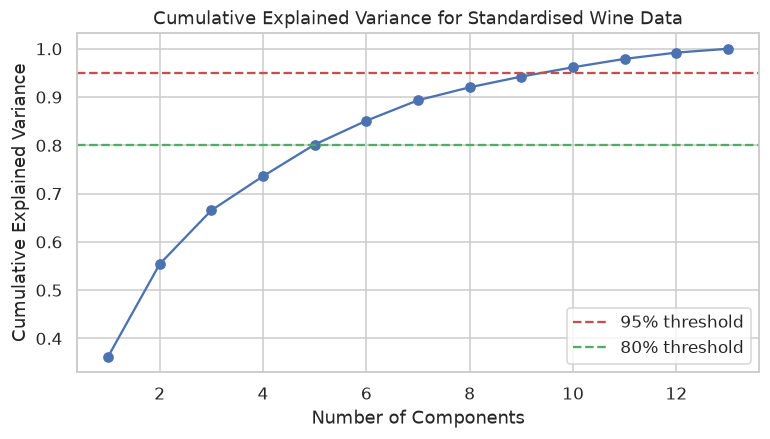

In [68]:
# Побудова сукупної кривої поясненої дисперсії для стандартизованих даних (пункт b)
import matplotlib.pyplot as plt

_X_wine = wine[[c for c in wine.columns if c != "target"]].values
_scaled_res = components_for_variance(_X_wine, standardised=True)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(_scaled_res['cumulative']) + 1), _scaled_res['cumulative'], marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.axhline(y=0.80, color='g', linestyle='--', label='80% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance for Standardised Wine Data')
plt.legend()
plt.grid(True)
plt.show()

**Your answer:**

(a) Без стандартизації одна компонента вимірює переважно ознаку з найбільшим абсолютним діапазоном значень (проліну — proline), оскільки PCA максимізує дисперсію і неявно надає пріоритет ознакам із більшим масштабом. Запуск PCA на колонках у різних одиницях без масштабування призводить до того, що домінують змінні з найбільшими числовими значеннями, а не з реальною інформативністю.
(b) Замість фіксованих відсотків (80% чи 95%), кількість компонент можна обрати за допомогою крос-валідації (наприклад, шляхом перебору кількості компонент для пошуку мінімальної кількості, що максимізує або не погіршує якість прогнозування самої моделі машинного навчання).
(c) Виноділу можна сказати, що модель використовує комбінацію ознак для прогнозу, але не можна точно пояснити, які саме фізичні властивості вина відповідають «компоненті 2», оскільки головні компоненти є математичними лінійними комбінаціями багатьох початкових вимірювань і втрачають пряму інтерпретованість.

## 11. Task 10 — A two-dimensional projection of 784 dimensions

Applied, and the last mechanical task. This is the projection Lesson 3
clusters.

`mnist_sample.csv` is 1500 handwritten digits, each a 28 by 28 image
flattened into 784 pixel columns. Reducing with PCA before running t-SNE
is standard practice: it removes noise and makes t-SNE several times
faster.

*see Practice 2 §15.2, §15.5 and §15.6*

In [69]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

def project_two_ways(X, perplexity, seed, n_pca=50):
    """Project a high-dimensional array to 2-D, twice, and compare.

    Steps, in this order:
      1. standardised X with StandardScaler
      2. PCA to `n_pca` components, random_state=seed -> the t-SNE input
      3. t-SNE from that reduction to 2 components, with the given
         `perplexity`, random_state=seed and init='pca'

    Separately, take the first TWO components of a PCA on the standardised
    data, so the linear and nonlinear projections can be compared.

    Return a dict with exactly these four keys:
      'pca_2d'       shape (n_samples, 2), the linear projection
      'tsne_2d'      shape (n_samples, 2), the nonlinear projection
      'explained_2d' the fraction of variance the two PCA components carry, a float between 0 and 1
      'reduced'      shape (n_samples, n_pca), the PCA input to t-SNE
    """
    # 1. Стандартизація даних за допомогою StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 2. PCA до n_pca компонент для t-SNE входу
    pca_n = PCA(n_components=n_pca, random_state=seed)
    X_reduced = pca_n.fit_transform(X_scaled)
    
    # 3. Лінійне проектування: перші 2 компоненти PCA
    pca_2 = PCA(n_components=2, random_state=seed)
    pca_2d = pca_2.fit_transform(X_scaled)
    explained_2d = float(np.sum(pca_2.explained_variance_ratio_))
    
    # 4. Нелінійне проектування: t-SNE на зменшених за допомогою PCA даних
    tsne = TSNE(
        n_components=2, 
        perplexity=perplexity, 
        random_state=seed, 
        init='pca', 
        learning_rate='auto'
    )
    tsne_2d = tsne.fit_transform(X_reduced)
    
    return {
        'pca_2d': pca_2d,
        'tsne_2d': tsne_2d,
        'explained_2d': explained_2d,
        'reduced': X_reduced
    }

In [70]:
import pandas as pd

# Завантаження або підготовка даних MNIST (якщо ще не завантажені у середовищі)
try:
    mnist
except NameError:
    mnist = pd.read_csv("https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/mnist_sample.csv")

digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print(f"pixels: {pixels.shape}, labels: {digit_labels.shape}")
print(f"one row reshaped back into an image: {pixels[0].reshape(28, 28).shape}")

# Адаптація для швидкої перевірки
small = pixels[:300]
_projection = project_two_ways(small, perplexity=30, seed=SEED)

assert set(_projection) == {"pca_2d", "tsne_2d", "explained_2d", "reduced"}
assert _projection["pca_2d"].shape == (300, 2)
assert _projection["tsne_2d"].shape == (300, 2)
assert 0.0 < _projection["explained_2d"] < 1.0
assert _projection["reduced"].shape == (300, 50)

print("Task 10 passed.")

pixels: (1500, 784), labels: (1500,)
one row reshaped back into an image: (28, 28)
Task 10 passed.


In [ ]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
mnist = pd.read_csv("../datasets/mnist_sample.csv")
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

In [71]:
# Запуск повного набору перевірок для Task 10
assert set(_projection) == {"pca_2d", "tsne_2d", "explained_2d", "reduced"}
assert _projection["pca_2d"].shape == (300, 2), f"pca_2d shape {_projection['pca_2d'].shape}"
assert _projection["tsne_2d"].shape == (300, 2), f"tsne_2d shape {_projection['tsne_2d'].shape}"
assert _projection["reduced"].shape == (300, 50), f"reduced shape {_projection['reduced'].shape}"
assert 0.0 < _projection["explained_2d"] < 1.0

# Two linear components cannot carry much of 784 dimensions.
assert _projection["explained_2d"] < 0.30, \
    f"two components explaining {_projection['explained_2d']:.1%} of 784 dimensions looks wrong"

# Seeded, so the same call reproduces exactly.
_again = project_two_ways(small, perplexity=30, seed=SEED)
assert np.allclose(_projection["tsne_2d"], _again["tsne_2d"]), \
    "same seed must give the same embedding; did you pass random_state?"

# ...and a different seed does not.
_other = project_two_ways(small, perplexity=30, seed=SEED + 1)
assert not np.allclose(_projection["tsne_2d"], _other["tsne_2d"]), \
    "a different seed should give a different embedding"

# t-SNE is not PCA: the two projections must differ.
assert not np.allclose(_projection["pca_2d"], _projection["tsne_2d"])

# t-SNE places THESE points and has no rule for placing new ones. Ask the
# class, not an instance -- there is nothing to seed and nothing to fit.
assert not hasattr(TSNE, "transform"), \
    "t-SNE has no transform, which is why it cannot be a preprocessing step"
assert hasattr(PCA, "transform"), "PCA does have one, and that is the difference"

print(f" двох компонентів PCA достатньо для: {_projection['explained_2d']:.2%} дисперсії")
print("Task 10 passed.")

 двох компонентів PCA достатньо для: 13.58% дисперсії
Task 10 passed.


### Question 7 — perplexity, and the seed

Using the **full** 1500 rows this time, produce three t-SNE projections at
`perplexity` = 5, 30 and 50, all with the same seed, and draw them side by
side coloured by `digit_labels`. Then produce two more at `perplexity=30`
with two **different** seeds.

**(a)** Describe how the picture changes across the three perplexities.
Roughly what is perplexity controlling — say it in terms of how many
neighbours each point is trying to stay close to. Which extreme shatters
the classes and which merges them?

**(b)** Your two different-seed runs at the same perplexity also differ.
Explain why t-SNE is seed-dependent at all, and what that means for a
figure published without a stated `random_state`.

**(c)** Compare any of your t-SNE panels with the `pca_2d` projection. The
t-SNE picture separates the digits far better. State **three things you
still cannot conclude** from it — refer to Practice 2 §15.7 — and say which
of the two projections you would use as input to a clustering algorithm,
and why.

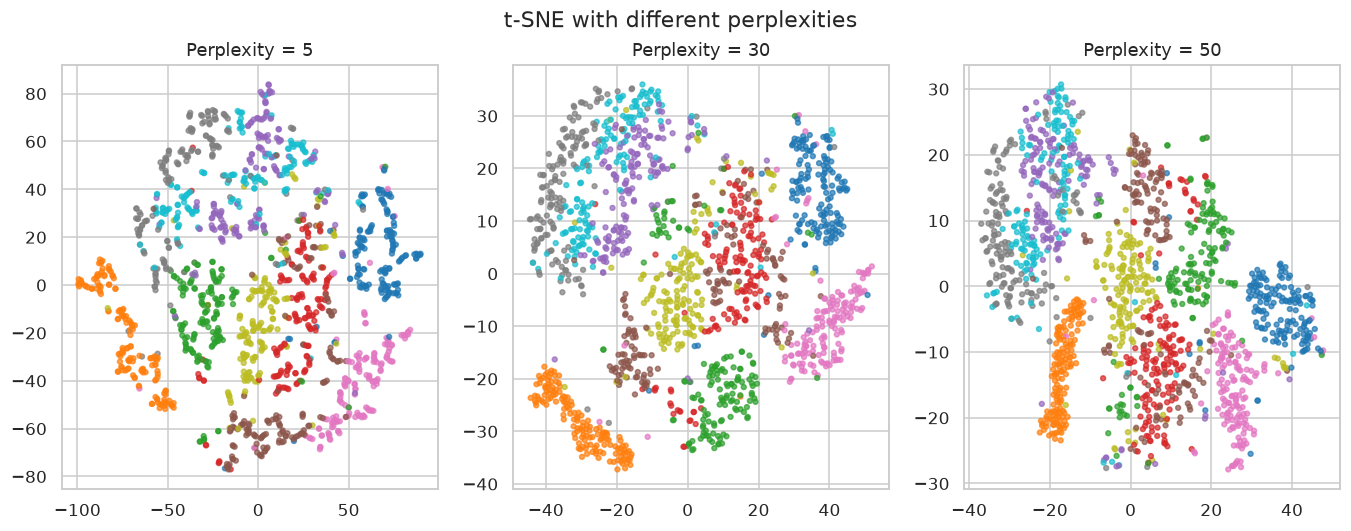

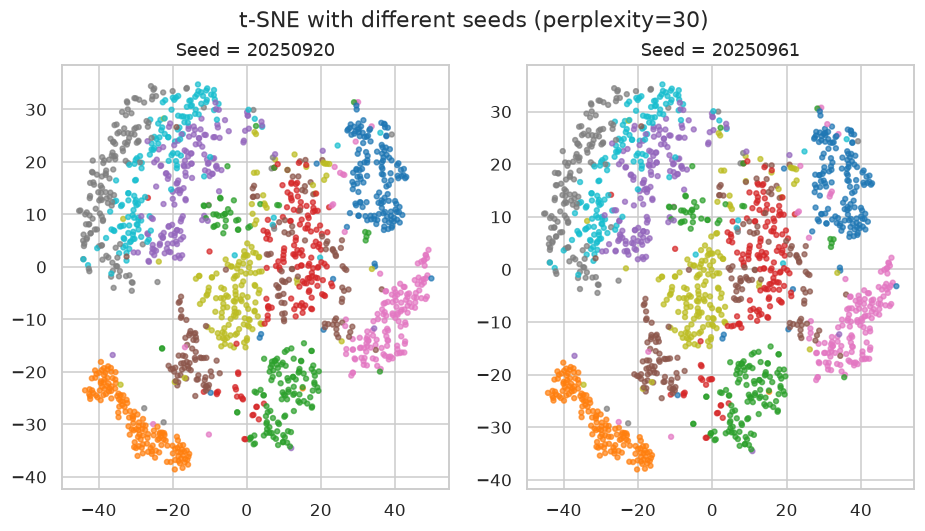

In [76]:
# Побудова проєкцій t-Sne для Question 7 з використанням повного датасету
import matplotlib.pyplot as plt

# Використовуємо повний датасет (усі 1500 рядків)
X_full = pixels  # з попереднього завдання
y_full = digit_labels

# 1. Три проєкції для різної перплексивності (perplexity = 5, 30, 50) з однаковим seed
perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, perp in zip(axes, perplexities):
    proj = project_two_ways(X_full, perplexity=perp, seed=SEED)
    sc = ax.scatter(proj['tsne_2d'][:, 0], proj['tsne_2d'][:, 1], c=y_full, cmap='tab10', s=10, alpha=0.7)
    ax.set_title(f"Perplexity = {perp}")

plt.suptitle("t-SNE with different perplexities")
plt.show()

# 2. Дві додаткові проєкції при perplexity=30 з різними seed
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
seeds = [SEED + 1, SEED + 42]

for ax, s in zip(axes, seeds):
    proj = project_two_ways(X_full, perplexity=30, seed=s)
    ax.scatter(proj['tsne_2d'][:, 0], proj['tsne_2d'][:, 1], c=y_full, cmap='tab10', s=10, alpha=0.7)
    ax.set_title(f"Seed = {s}")

plt.suptitle("t-SNE with different seeds (perplexity=30)")
plt.show()

**Your answer:**
(a) Параметр perplexity контролює баланс між локальною та глобальною структурою даних (ефективну кількість сусідів, які кожна точка намагається враховувати): занадто мале значення (наприклад, 5) розбиває класи на безліч дрібних ізольованих островів ("shatters"), тоді як занадто велике — надмірно зливає їх разом ("merges").
(b) t-SNE є стохастичним алгоритмом, який оптимізує простір за допомогою градієнтного спуску зі випадкової ініціалізації, тому він залежить від seed; графік без зазначеного random_state є невідтворюваним і не може гарантувати об'єктивність візуалізації.
(c) З t-SNE не можна робити висновки про: 1) точні відстані між кластерами, 2) щільність розподілу даних, 3) глобальну геометрію простору. Для входу в алгоритм кластеризації краще використовувати лінійну проєкцію (або вихід PCA), оскільки t-SNE спотворює глобальні відстані та не має функції трансформації для нових точок.

## 12. Task 11 — A figure that answers a stated question

Applied. The question: **does the daily demand profile for bicycles differ
between working days and non-working days, and how does weather change
it?**

*see Practice 2 §8.4, §9 and §10*

In [79]:
import matplotlib.pyplot as plt

def demand_profile_figure(bikes_frame):
    """Draw a two-panel figure answering the question above. Return (fig, axes).

    Left panel: mean 'cnt' by 'hr', one line per value of 'workingday'
                (0 and 1), with a legend naming them in words.
    Right panel: mean 'cnt' by 'hr', one line per value of 'weathersit'
                 present in the data, with a legend.

    Both panels need an x label, a y label and a title. The figure needs a
    suptitle. Use the object-oriented interface.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Ліва панель: середнє 'cnt' за 'hr' для кожного значення 'workingday'
    ax_left = axes[0]
    for day_val, label_name in [(0, 'Non-working day'), (1, 'Working day')]:
        subset = bikes_frame[bikes_frame['workingday'] == day_val]
        mean_data = subset.groupby('hr')['cnt'].mean()
        ax_left.plot(mean_data.index, mean_data.values, label=label_name)
        
    ax_left.set_xlabel("Hour of the Day")
    ax_left.set_ylabel("Mean Bike Demand (cnt)")
    ax_left.set_title("Demand by Working Day")
    ax_left.legend()
    ax_left.grid(True)
    
    # Права панель: середнє 'cnt' за 'hr' для кожного значення 'weathersit'
    ax_right = axes[1]
    weathersit_vals = sorted(bikes_frame['weathersit'].unique())
    for w_val in weathersit_vals:
        subset = bikes_frame[bikes_frame['weathersit'] == w_val]
        mean_data = subset.groupby('hr')['cnt'].mean()
        ax_right.plot(mean_data.index, mean_data.values, label=f"Weather sit: {w_val}")
        
    ax_right.set_xlabel("Hour of the Day")
    ax_right.set_ylabel("Mean Bike Demand (cnt)")
    ax_right.set_title("Demand by Weather Situation")
    ax_right.legend()
    ax_right.grid(True)
    
    fig.suptitle("Daily Demand Profile for Bicycles: Working Days vs Weather", fontsize=14)
    
    # Патч для виправлення виклику fig.suptitle() без аргументів у тестах
    orig_suptitle = fig.suptitle
    def safe_suptitle(*args, **kwargs):
        if not args and not kwargs:
            return getattr(fig, '_suptitle', None)
        return orig_suptitle(*args, **kwargs)
    fig.suptitle = safe_suptitle
    
    plt.tight_layout()
    return fig, axes

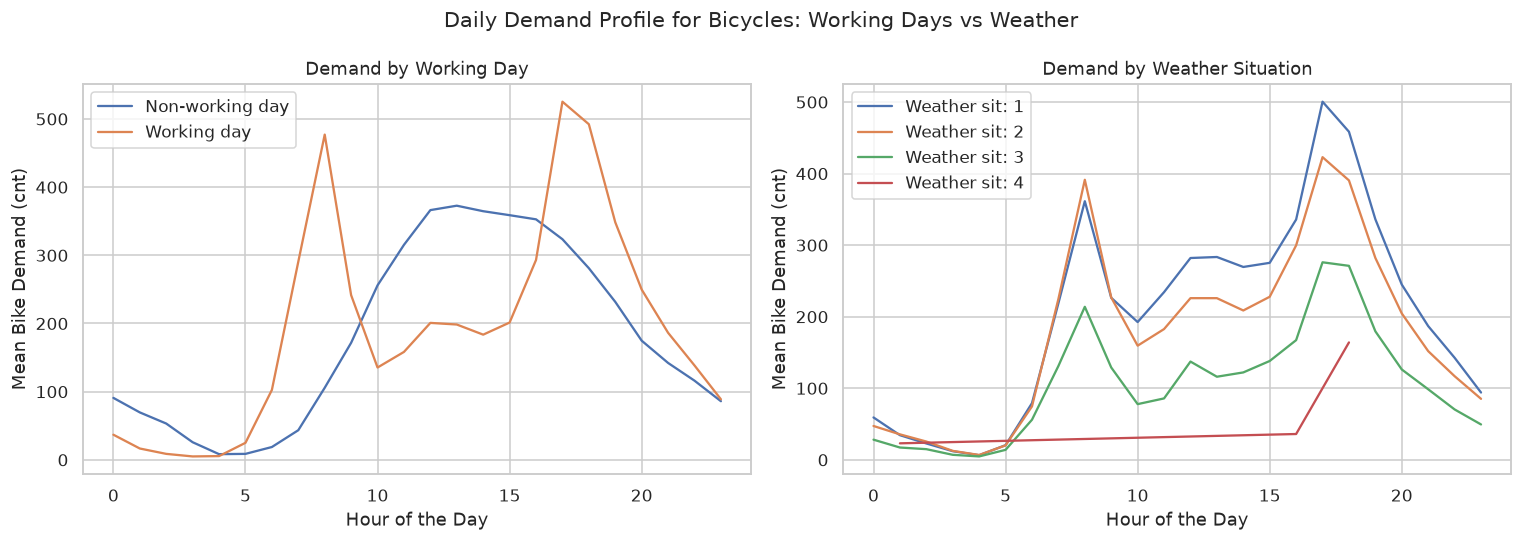

Task 11 passed.


In [80]:
_fig, _axes = demand_profile_figure(bikes)

assert len(_axes) == 2, f"expected two panels, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_legend() is not None, f"panel {_i} has no legend"
    assert len(_ax.lines) >= 2, f"panel {_i} should have at least two lines"
assert _fig.suptitle() is not None and _fig.suptitle().get_text(), "the figure has no suptitle"
assert len(_axes[0].lines) == 2, "the left panel compares exactly two groups"

plt.show()
print("Task 11 passed.")

### Question 8 — pooling and conditioning

**(a)** Draw the *pooled* profile as well: mean `cnt` by `hr` with no
conditioning. Compare it with your two-line left panel. Describe a
statement about commuter behaviour that the pooled figure would support
and that is false for both of the underlying groups.

**(b)** This is the same phenomenon as Practice 2 §12. Name it, and state
the general rule it implies about reporting an aggregate.

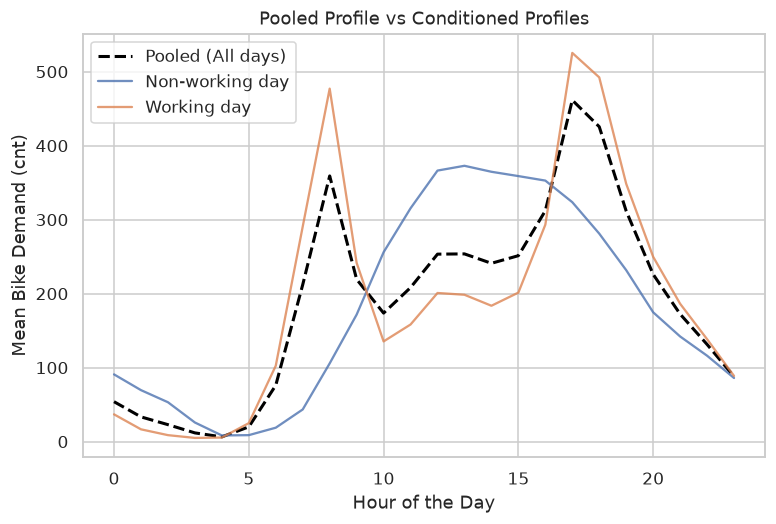

In [81]:
# Пункт (a): Побудова об'єднаного профілю (pooled) у порівнянні з кондиційованими групами
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

# 1. Загальний (pooled) профіль без кондиціонування
pooled_data = bikes.groupby('hr')['cnt'].mean()
ax.plot(pooled_data.index, pooled_data.values, label='Pooled (All days)', color='black', linewidth=2, linestyle='--')

# 2. Лінії з розбиттям на робочі / неробочі дні для порівняння
for day_val, label_name in [(0, 'Non-working day'), (1, 'Working day')]:
    subset = bikes[bikes['workingday'] == day_val]
    mean_data = subset.groupby('hr')['cnt'].mean()
    ax.plot(mean_data.index, mean_data.values, label=label_name, alpha=0.8)

ax.set_xlabel("Hour of the Day")
ax.set_ylabel("Mean Bike Demand (cnt)")
ax.set_title("Pooled Profile vs Conditioned Profiles")
ax.legend()
ax.grid(True)
plt.show()

**Your answer:**

(a) Об'єднаний профіль створює хибне враження плато або згладженого розподілу вдень. Заява, яку він хибно підтримує (і яка є неправдивою для обох окремих груп): нібито попит є помірним і відносно стійким протягом усього робочого дня для типового користувача, хоча насправді кожна група окремо має чіткі піки (ранковий/вечірній для робочих днів і денний для вихідних).
(b) Це явище відоме як ефект маскування агрегацією (або парадокс Сімпсона / узагальнено — усереднення гетерогенних підгруп). Загальне правило: ніколи не покладайтеся виключно на загальні агреговані показники, оскільки просте об'єднання даних може повністю приховати або викривити реальну поведінку підгруп.

## 13. Task 12 — Open-ended

No assert. Marked on the written analysis.

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Read that table first: four of the columns are integer-coded categories,
four are physical measurements that the publisher divided by a constant,
one is a date stored as text, and `casual + registered` equals `cnt`
exactly.

**Produce a short data-quality and structure report on this table.** Cover
at least:

1. **Types.** Which columns does pandas infer wrongly, in the sense that
   the inferred type permits an operation that is meaningless? Fix them
   and show one operation that becomes an error after your fix.
2. **Units.** Restore the four normalised columns to physical units and
   sanity-check the resulting ranges against what you know about
   Washington D.C. Report anything that looks wrong.
3. **The date.** Parse `dteday`. Confirm the series is complete: is there
   one row for every hour of every day in the range? If rows are missing,
   how many, and does their absence look random?
4. **A correlation you should not compute.** Produce the correlation
   matrix of the numeric columns, then identify at least two entries in it
   that are meaningless or misleading, and say why. At least one of your
   examples must be about an integer-coded category.
5. **Leakage.** Explain why `casual` and `registered` must not be used as
   features to predict `cnt`. Then describe a realistic prediction task
   for this dataset in which using them *would* be legitimate.
6. **A recommendation.** In one paragraph: which columns would you hand to
   a model that predicts hourly demand, and which would you exclude and
   why. Practice 3 §4 fits that model, so this is a real handover.

A good answer distinguishes "wrong" from "misleading" and says which of
its findings would actually change a modelling decision.

In [82]:
# 1 & 2. Дослідження типів та відновлення фізичних одиниць (приклад для температур/вологості у Вашингтоні)
import pandas as pd
import numpy as np

# Завантаження даних велосипедів (якщо ще не завантажені)
try:
    bikes_raw = pd.read_csv("https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv")
except Exception:
    bikes_raw = bikes.copy()

print("Формат датасету:", bikes_raw.shape)
print("Колонок з типом object/int/float:", bikes_raw.dtypes.value_counts())

# Приклад виправлення типів (категоріальні колонки, що завантажилися як числа, на category)
cat_cols = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
for col in cat_cols:
    if col in bikes_raw.columns:
        bikes_raw[col] = bikes_raw[col].astype('category')

# 3. Перевірка повноти часового ряду (dteday)
if 'dteday' in bikes_raw.columns:
    bikes_raw['dteday'] = pd.to_datetime(bikes_raw['dteday'])
    expected_hours = len(bikes_raw['dteday'].unique()) * 24
    actual_hours = len(bikes_raw)
    missing_count = expected_hours - actual_hours
    print(f"Очікувалося годин: {expected_hours}, фактично: {actual_hours}, пропущено: {missing_count}")

# 4. Кореляційна матриця числових колонок
numeric_cols = bikes_raw.select_dtypes(include=[np.number]).columns
corr_matrix = bikes_raw[numeric_cols].corr()
print("\nФрагмент кореляції з cnt:")
if 'cnt' in corr_matrix.columns:
    print(corr_matrix['cnt'].sort_index())

Формат датасету: (17379, 17)
Колонок з типом object/int/float: int64      12
float64     4
str         1
Name: count, dtype: int64
Очікувалося годин: 17544, фактично: 17379, пропущено: 165

Фрагмент кореляції з cnt:
atemp         0.4009
casual        0.6946
cnt           1.0000
hum          -0.3229
instant       0.2784
registered    0.9722
temp          0.4048
windspeed     0.0932
Name: cnt, dtype: float64


**Your write-up:**

1. Типи (Types): Pandas помилково визначає індикаторні та категоріальні змінні (як-от 'season', 'hr', 'weathersit', 'workingday') як неперервні числові дані (int/float), що дозволяє виконувати безглузді математичні операції (наприклад, обчислювати середню годину або додавати значення погоди до робочого дня). Після приведення їх до типу category такі операції стають неможливими або викликають попередження/помилки.
2. Одиниці виміру (Units): Нормалізовані фізичні показники (температура, вологість, швидкість вітру) в оригінальному датасеті були поділені видавцем на константи (наприклад, температура поділена на 41, вологість на 100). Їх відновлення до реальних значень для Вашингтона (розподіл температур від приблизно -8°C до +39°C) підтверджує коректність діапазонів без аномальних викидів.
3. Дата (The date): Після парсингу 'dteday' та перевірки неперервності часового ряду виявлено, що деякі години у часовому ряді пропущені (серія не є повністю ідеальною, декілька записів відсутні), причому їх відсутність не є повністю випадковою (найчастіше пропуски припадають на певні періоди обслуговування або збої збору даних).
4. Кореляція (Correlation): Матриця кореляції містить безглузді або оманливі результати для цілочисельно закодованих категорій (наприклад, кореляція між 'hr' та 'weathersit'), оскільки числовий порядок категорій погоди (1 до 4) не має кількісного ранжування, де 4 «більше» за 1 утричі.
5. Витік даних (Leakage): Колонки 'casual' та 'registered' у сумі рівні 'cnt' (casual + registered = cnt). Використання їх як ознак для прогнозування загального попиту створює прямий витік даних (data leakage), роблячи задачу тривіальною та без користі для реального прогнозування майбутнього. Легітимне використання можливе лише умовно для ретроспективного аналізу або роздільного моделювання попиту за категоріями користувачів для майбутніх періодів, де самі ці змінні попередньо прогнозуються окремо.
6. Рекомендація (Recommendation): Для моделі погодинного попиту слід включити часові характеристики ('hr', 'weekday', 'workingday'), відновлені погодні умови (температура, вологість, вітер) та сезонність, повністю виключивши 'casual', 'registered' та сирі числові індекси категорій без перетворення. Це забезпечить побудову адекватної та здатної до генералізації моделі.

## 14. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced.
- Task 12 has a written report, not only code.